# 04 Fear Extinction

Sparse Hopfield network with **component-specific β**: CS, context, and US drives are summed into a fixed external field vector; fear conditioning uses positive US drive, extinction uses **negative US drive** (inhibition). Top-k dynamics use `h = W·s + field + θ` each step.

In [10]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern
from engram.metrics import pattern_overlap, activity_fraction

_cwd = Path.cwd()
FIGDIR = (_cwd / "figures") if _cwd.name == "notebooks" else (_cwd / "notebooks" / "figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- Section A: parameters ---
N = 2000
SPARSITY = 0.10
K = int(SPARSITY * N)
P_OLD = 42
SEED = 42
rng = np.random.default_rng(SEED)

CUE_FRAC = 0.03
N_CUE = int(CUE_FRAC * N)

CS_US_CORRELATION = 0.0

# Component-specific beta values
# Positive = excitatory drive toward engram
# Negative = inhibitory suppression during extinction
BETA_CS_FEAR = 0.3  # stronger CS drive during fear storage — more CS neurons in fear engram
BETA_CS_EXT = 0.1  # weaker CS drive during extinction — avoids CS dominating ext engram
BETA_CTX_FEAR_STORE = 0.55  # fear context: strong drive during fear conditioning
BETA_CTX_EXT_STORE = 0.55  # extinction context: normal drive during extinction storage
BETA_CTX_RETRIEVAL = 0.45  # context drive at test / retrieval
BETA_US_FEAR = 0.25
BETA_US_EXT = -0.45  # fixed extinction US inhibition used throughout notebook

SIGMA_THETA = 0.03
MAX_STEPS_STORAGE = 20
MAX_STEPS_RETRIEVAL = 20
N_RETRIEVAL_TRIALS = 20

print("Section A complete")


Section A complete


**Part 1 rationale.** `N_CUE = 60` per component, `P_OLD = 25`. External input is **per-component β × binary cue**, summed into a vector field (not a single global `BETA × clipped cue`). Extinction applies **negative β on US** to suppress US-predictive neurons while CS and extinction context stay excitatory.

## Part 2: Cue vectors and external fields

CS, US, and contexts stay **separate**; combined drive is `compute_ext_field(components)`.

**Rationale:** Fear uses CS + US + fear context (all positive β). Extinction uses CS + extinction context (positive) and **US with negative β** (active inhibition in the field, not absence).

In [11]:
def make_cue_component(N, n_active, rng):
    vec = np.zeros(N)
    idx = rng.choice(N, n_active, replace=False)
    vec[idx] = 1.0
    return vec, idx


def make_correlated_components(N, n_active, correlation, rng):
    n_shared = int(correlation * n_active)
    n_unique = n_active - n_shared
    shared_idx = rng.choice(N, n_shared, replace=False)
    remaining = np.setdiff1d(np.arange(N), shared_idx)
    unique1_idx = rng.choice(remaining, n_unique, replace=False)
    remaining2 = np.setdiff1d(remaining, unique1_idx)
    unique2_idx = rng.choice(remaining2, n_unique, replace=False)
    vec1 = np.zeros(N)
    vec1[shared_idx] = 1.0
    vec1[unique1_idx] = 1.0
    vec2 = np.zeros(N)
    vec2[shared_idx] = 1.0
    vec2[unique2_idx] = 1.0
    return vec1, vec2, shared_idx, unique1_idx, unique2_idx


def compute_ext_field(components):
    # Sum beta_i * x_i across all cue components.
    # components: dict of {name: (vector, beta)}
    # Returns combined external field vector of shape (N,)
    field = np.zeros(N)
    for name, (vec, beta) in components.items():
        field += beta * vec
    return field


cs_vec, us_vec, cs_us_shared, cs_unique, us_unique = make_correlated_components(
    N, N_CUE, CS_US_CORRELATION, rng
)
ctx_fear_vec, ctx_fear_idx = make_cue_component(N, N_CUE, rng)
ctx_ext_vec, ctx_ext_idx = make_cue_component(N, N_CUE, rng)

print(
    f"CS neurons: {N_CUE}  |  US: {N_CUE}  |  CS-US shared: {len(cs_us_shared)}"
)
print(
    f"Ctx-fear vs CS overlap: {int(np.dot(ctx_fear_vec, cs_vec))}  |  "
    f"Ctx-ext vs CS: {int(np.dot(ctx_ext_vec, cs_vec))}"
)

fear_components = {
    "cs": (cs_vec, BETA_CS_FEAR),
    "us": (us_vec, BETA_US_FEAR),
    "ctx": (ctx_fear_vec, BETA_CTX_FEAR_STORE),
}

print("Part 2a complete: cue vectors and fear_components")


CS neurons: 60  |  US: 60  |  CS-US shared: 0
Ctx-fear vs CS overlap: 2  |  Ctx-ext vs CS: 1
Part 2a complete: cue vectors and fear_components


In [12]:
# --- Section B: extinction components and combined fields ---

ext_components = {
    "cs": (cs_vec, BETA_CS_EXT),
    "us": (us_vec, BETA_US_EXT),
    "ctx": (ctx_ext_vec, BETA_CTX_EXT_STORE),
}

fear_ext_field = compute_ext_field(fear_components)
ext_ext_field = compute_ext_field(ext_components)
ext_init_state = (ext_ext_field > 0).astype(float)


def _m(x):
    return float(np.mean(x)) if x.size else float("nan")


cue_union_fear = (cs_vec + us_vec + ctx_fear_vec).clip(0, 1)
bg_fear = (cue_union_fear == 0)

print("Fear external field stats:")
print(f"  Mean over CS neurons:       {_m(fear_ext_field[cs_vec == 1]):.4f}")
print(f"  Mean over US neurons:       {_m(fear_ext_field[us_vec == 1]):.4f}")
print(f"  Mean over fear ctx neurons: {_m(fear_ext_field[ctx_fear_vec == 1]):.4f}")
print(f"  Mean over background:       {_m(fear_ext_field[bg_fear]):.4f}")

cue_union_ext = (cs_vec + us_vec + ctx_ext_vec).clip(0, 1)
bg_ext = (cue_union_ext == 0)

print("\nExtinction external field stats:")
print(f"  Mean over CS neurons:       {_m(ext_ext_field[cs_vec == 1]):.4f}")
print(f"  Mean over US neurons:       {_m(ext_ext_field[us_vec == 1]):.4f}")
print(f"  Mean over ext ctx neurons:  {_m(ext_ext_field[ctx_ext_vec == 1]):.4f}")
print(f"  Mean over background:       {_m(ext_ext_field[bg_ext]):.4f}")
print("(US neurons should have negative mean in extinction field)")

print("Section B complete")


Fear external field stats:
  Mean over CS neurons:       0.3183
  Mean over US neurons:       0.2592
  Mean over fear ctx neurons: 0.5642
  Mean over background:       0.0000

Extinction external field stats:
  Mean over CS neurons:       0.1092
  Mean over US neurons:       -0.4317
  Mean over ext ctx neurons:  0.5367
  Mean over background:       0.0000
(US neurons should have negative mean in extinction field)
Section B complete


## Background Hopfield network

Initialize `net` and `old_patterns` (uses `rng`).

In [13]:
net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)

old_patterns = [
    generate_sparse_pattern(N, SPARSITY, rng=rng).astype(float) for _ in range(P_OLD)
]
net.store_patterns(old_patterns)

print(f"Network initialized with P={P_OLD} background memories")


Network initialized with P=42 background memories


## Part 3: Field scale diagnostic

Uses `fear_ext_field` from Part 2 / Section B.

In [14]:
mean_w = np.mean(np.abs(net.W))
recurrent_scale = K * mean_w
beta_eff = max(
    BETA_CS_FEAR,
    BETA_CS_EXT,
    BETA_CTX_FEAR_STORE,
    BETA_CTX_EXT_STORE,
    BETA_CTX_RETRIEVAL,
    BETA_US_FEAR,
    abs(BETA_US_EXT),
)
ratio = beta_eff / recurrent_scale

print(f"Mean |W|:            {mean_w:.6f}")
print(f"Recurrent field scale (K * mean|W|): {recurrent_scale:.4f}")
print(f"Effective beta scale (max |component β|): {beta_eff:.4f}")
print(f"Cue-to-recurrent ratio (heuristic): {ratio:.3f}")
print("Target cue-to-recurrent ratio:        0.25 - 0.45 (rule-of-thumb)")

n_cue_total = int((fear_ext_field > 0).sum())
competition_ratio = n_cue_total / K
print(f"Cue neurons (binary CS+US+fear-ctx union) / K: {competition_ratio:.2f}")
print("(Should be > 1.5 so there is real competition for K slots)")

print("Part 3 complete")


Mean |W|:            0.002563
Recurrent field scale (K * mean|W|): 0.5125
Effective beta scale (max |component β|): 0.5500
Cue-to-recurrent ratio (heuristic): 1.073
Target cue-to-recurrent ratio:        0.25 - 0.45 (rule-of-thumb)
Cue neurons (binary CS+US+fear-ctx union) / K: 0.89
(Should be > 1.5 so there is real competition for K slots)
Part 3 complete


## Excitability

Session-specific `theta_fear`, `theta_ext`.

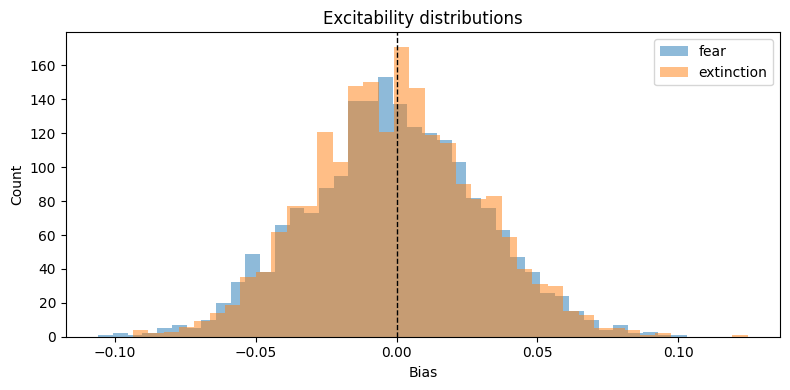

In [15]:
theta_fear = rng.normal(0, SIGMA_THETA, N)
theta_ext = rng.normal(0, SIGMA_THETA, N)

plt.figure(figsize=(8, 4))
plt.hist(theta_fear, bins=40, alpha=0.5, label="fear")
plt.hist(theta_ext, bins=40, alpha=0.5, label="extinction")
plt.axvline(0.0, color="k", linestyle="--", linewidth=1)
plt.title("Excitability distributions")
plt.xlabel("Bias")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "04_excitability_distributions.png", dpi=150)
plt.show()


## Section C: Fear storage (top-k)

Fear convergence steps: 15
Activity at convergence: 0.100
Fear vs CS: 0.167 (chance=0.100, ABOVE chance)
Fear vs US: 0.150 (chance=0.100, near chance)
Fear vs Fear ctx: 0.117 (chance=0.100, near chance)
Fear vs Ext ctx: 0.133 (chance=0.100, near chance)


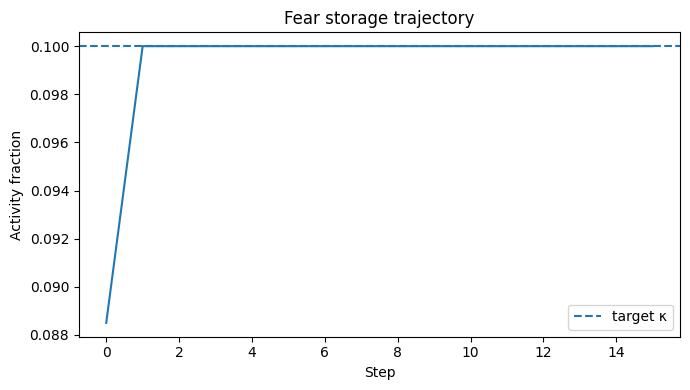

Section C complete


In [16]:
state = (fear_ext_field > 0).astype(float)
traj_fear = [state.copy()]
for step in range(MAX_STEPS_STORAGE):
    h = net.W @ state + fear_ext_field + theta_fear
    topk_idx = np.argpartition(h, -K)[-K:]
    new_state = np.zeros(N)
    new_state[topk_idx] = 1.0
    traj_fear.append(new_state.copy())
    if np.array_equal(new_state, state):
        break
    state = new_state

fear_engram = state.copy()
assert int(fear_engram.sum()) == K

net.store_pattern_sequential(fear_engram)

print(f"Fear convergence steps: {len(traj_fear) - 1}")
print(f"Activity at convergence: {activity_fraction(fear_engram):.3f}")

chance = SPARSITY
for name, vec in [
    ("CS", cs_vec),
    ("US", us_vec),
    ("Fear ctx", ctx_fear_vec),
    ("Ext ctx", ctx_ext_vec),
]:
    overlap = np.sum(fear_engram * vec) / N_CUE
    tag = "ABOVE" if overlap > chance * 1.5 else "near"
    print(f"Fear vs {name}: {overlap:.3f} (chance={chance:.3f}, {tag} chance)")

plt.figure(figsize=(7, 4))
plt.plot([activity_fraction(s) for s in traj_fear])
plt.axhline(SPARSITY, linestyle="--", label="target κ")
plt.xlabel("Step")
plt.ylabel("Activity fraction")
plt.title("Fear storage trajectory")
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "04_fear_convergence.png", dpi=150)
plt.show()

print("Section C complete")


## Section D: Field at extinction onset (negative β_US)

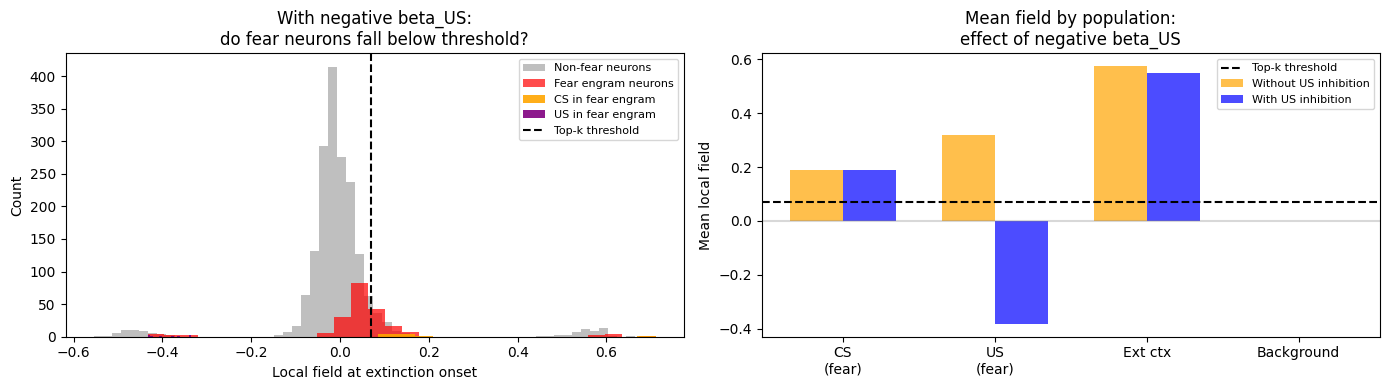

Ext cue (with neg beta_US) retrieves fear: 1.000
(Target < 0.5 — if still > 0.9 increase |BETA_US_EXT|)
Section D complete


In [17]:
ext_init_state = (ext_ext_field > 0).astype(float)
h_at_onset = net.W @ ext_init_state + ext_ext_field

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(h_at_onset[fear_engram == 0], bins=60, alpha=0.5, color="gray", label="Non-fear neurons")
ax.hist(h_at_onset[fear_engram == 1], bins=30, alpha=0.7, color="red", label="Fear engram neurons")
cs_fear_mask = (fear_engram == 1) & (cs_vec == 1)
us_fear_mask = (fear_engram == 1) & (us_vec == 1)
if cs_fear_mask.any():
    ax.hist(h_at_onset[cs_fear_mask], bins=15, alpha=0.9, color="orange", label="CS in fear engram")
if us_fear_mask.any():
    ax.hist(h_at_onset[us_fear_mask], bins=15, alpha=0.9, color="purple", label="US in fear engram")
threshold = np.sort(h_at_onset)[-K]
ax.axvline(threshold, color="black", linestyle="--", label="Top-k threshold")
ax.set_xlabel("Local field at extinction onset")
ax.set_ylabel("Count")
ax.set_title("With negative beta_US:\ndo fear neurons fall below threshold?")
ax.legend(fontsize=8)

h_without_inhibit = net.W @ ext_init_state + compute_ext_field(
    {
        "cs": (cs_vec, BETA_CS_EXT),
        "us": (us_vec, BETA_US_FEAR),
        "ctx": (ctx_ext_vec, BETA_CTX_EXT_STORE),
    }
)

populations = ["CS\n(fear)", "US\n(fear)", "Ext ctx", "Background"]
masks = [
    cs_fear_mask,
    us_fear_mask,
    ctx_ext_vec == 1,
    (cs_vec + us_vec + ctx_fear_vec + ctx_ext_vec) == 0,
]
means_with = [float(np.mean(h_at_onset[m])) if m.any() else float("nan") for m in masks]
means_without = [float(np.mean(h_without_inhibit[m])) if m.any() else float("nan") for m in masks]

x = np.arange(len(populations))
w = 0.35
axes[1].bar(x - w / 2, means_without, w, color="orange", alpha=0.7, label="Without US inhibition")
axes[1].bar(x + w / 2, means_with, w, color="blue", alpha=0.7, label="With US inhibition")
axes[1].axhline(np.sort(h_at_onset)[-K], color="black", linestyle="--", label="Top-k threshold")
axes[1].axhline(0, color="gray", linestyle="-", alpha=0.3)
axes[1].set_xticks(x)
axes[1].set_xticklabels(populations)
axes[1].set_ylabel("Mean local field")
axes[1].set_title("Mean field by population:\neffect of negative beta_US")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGDIR / "04_field_distribution.png", dpi=150)
plt.show()

state_test = ext_init_state.copy()
for step in range(MAX_STEPS_RETRIEVAL):
    h = net.W @ state_test + ext_ext_field + theta_ext
    idx = np.argpartition(h, -K)[-K:]
    ns = np.zeros(N)
    ns[idx] = 1.0
    if np.array_equal(ns, state_test):
        break
    state_test = ns
capture = pattern_overlap(state_test, fear_engram)
print(f"Ext cue (with neg beta_US) retrieves fear: {capture:.3f}")
print("(Target < 0.5 — if still > 0.9 increase |BETA_US_EXT|)")

print("Section D complete")


## Trajectory comparison: extinction dynamics

Same network and `fear_engram`; compare extinction storage trajectories for two US-extinction betas.

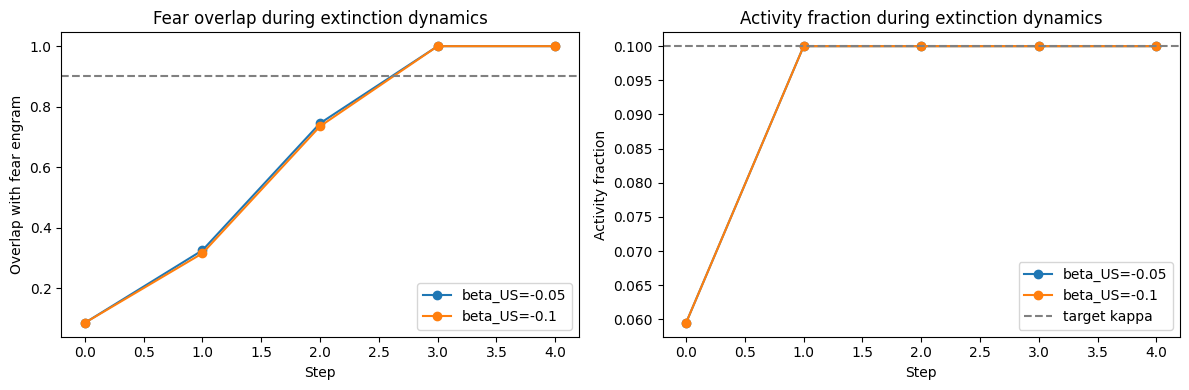

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, bval in enumerate([-0.05, -0.10]):
    ext_field_test = compute_ext_field({
        "cs": (cs_vec, BETA_CS_EXT),
        "us": (us_vec, bval),
        "ctx": (ctx_ext_vec, BETA_CTX_EXT_STORE),
    })
    init = (ext_field_test > 0).astype(float)
    state = init.copy()
    fear_overlaps = [pattern_overlap(state, fear_engram)]
    activity = [activity_fraction(state)]

    for step in range(MAX_STEPS_STORAGE):
        h = net.W @ state + ext_field_test + theta_ext
        idx = np.argpartition(h, -K)[-K:]
        ns = np.zeros(N)
        ns[idx] = 1.0
        fear_overlaps.append(pattern_overlap(ns, fear_engram))
        activity.append(activity_fraction(ns))
        if np.array_equal(ns, state):
            break
        state = ns

    axes[0].plot(fear_overlaps, marker="o", label=f"beta_US={bval}")
    axes[1].plot(activity, marker="o", label=f"beta_US={bval}")

axes[0].set_title("Fear overlap during extinction dynamics")
axes[0].set_ylabel("Overlap with fear engram")
axes[0].set_xlabel("Step")
axes[0].axhline(0.9, linestyle="--", color="gray")
axes[0].legend()

axes[1].set_title("Activity fraction during extinction dynamics")
axes[1].set_ylabel("Activity fraction")
axes[1].set_xlabel("Step")
axes[1].axhline(0.10, linestyle="--", color="gray", label="target kappa")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGDIR / "04_extinction_trajectory_comparison.png", dpi=150)
plt.show()


In [19]:
def make_cue_component(N, n_active, rng):
    vec = np.zeros(N)
    idx = rng.choice(N, n_active, replace=False)
    vec[idx] = 1.0
    return vec, idx


def make_correlated_components(N, n_active, correlation, rng):
    n_shared = int(correlation * n_active)
    n_unique = n_active - n_shared
    shared_idx = rng.choice(N, n_shared, replace=False)
    remaining = np.setdiff1d(np.arange(N), shared_idx)
    unique1_idx = rng.choice(remaining, n_unique, replace=False)
    remaining2 = np.setdiff1d(remaining, unique1_idx)
    unique2_idx = rng.choice(remaining2, n_unique, replace=False)
    vec1 = np.zeros(N)
    vec1[shared_idx] = 1.0
    vec1[unique1_idx] = 1.0
    vec2 = np.zeros(N)
    vec2[shared_idx] = 1.0
    vec2[unique2_idx] = 1.0
    return vec1, vec2, shared_idx, unique1_idx, unique2_idx


def compute_ext_field(components):
    # Sum beta_i * x_i across all cue components.
    # components: dict of {name: (vector, beta)}
    # Returns combined external field vector of shape (N,)
    field = np.zeros(N)
    for name, (vec, beta) in components.items():
        field += beta * vec
    return field


cs_vec, us_vec, cs_us_shared, cs_unique, us_unique = make_correlated_components(
    N, N_CUE, CS_US_CORRELATION, rng
)
ctx_fear_vec, ctx_fear_idx = make_cue_component(N, N_CUE, rng)
ctx_ext_vec, ctx_ext_idx = make_cue_component(N, N_CUE, rng)

print(
    f"CS neurons: {N_CUE}  |  US: {N_CUE}  |  CS-US shared: {len(cs_us_shared)}"
)
print(
    f"Ctx-fear vs CS overlap: {int(np.dot(ctx_fear_vec, cs_vec))}  |  "
    f"Ctx-ext vs CS: {int(np.dot(ctx_ext_vec, cs_vec))}"
)

fear_components = {
    "cs": (cs_vec, BETA_CS_FEAR),
    "us": (us_vec, BETA_US_FEAR),
    "ctx": (ctx_fear_vec, BETA_CTX_FEAR_STORE),
}

print("Part 2a complete: cue vectors and fear_components")


CS neurons: 60  |  US: 60  |  CS-US shared: 0
Ctx-fear vs CS overlap: 2  |  Ctx-ext vs CS: 1
Part 2a complete: cue vectors and fear_components


## Section E: Extinction storage (top-k)

In [20]:
state = ext_init_state.copy()
traj_ext = [state.copy()]
for step in range(MAX_STEPS_STORAGE):
    h = net.W @ state + ext_ext_field + theta_ext
    topk_idx = np.argpartition(h, -K)[-K:]
    new_state = np.zeros(N)
    new_state[topk_idx] = 1.0
    traj_ext.append(new_state.copy())
    if np.array_equal(new_state, state):
        break
    state = new_state

ext_engram = state.copy()
assert int(ext_engram.sum()) == K

net.store_pattern_sequential(ext_engram)

print(f"Extinction convergence steps: {len(traj_ext) - 1}")
print(f"Activity at convergence: {activity_fraction(ext_engram):.3f}")

print(f"{'Component':<12} {'N_CUE':>6} {'Fear':>8} {'Ext':>8} {'Chance':>8}")
print("-" * 46)
for name, vec in [
    ("CS", cs_vec),
    ("US", us_vec),
    ("Fear ctx", ctx_fear_vec),
    ("Ext ctx", ctx_ext_vec),
]:
    n = int(vec.sum())
    f_ov = np.sum(fear_engram * vec) / n
    e_ov = np.sum(ext_engram * vec) / n
    print(f"{name:<12} {n:>6} {f_ov:>8.3f} {e_ov:>8.3f} {SPARSITY:>8.3f}")

phi = np.sum(fear_engram * ext_engram) / K
phi_cs = np.sum(fear_engram * ext_engram * cs_vec) / K
phi_us = np.sum(fear_engram * ext_engram * us_vec) / K

print(f"\nPhi total:   {phi:.3f}")
print(f"Phi via CS:  {phi_cs:.3f}")
print(f"Phi via US:  {phi_us:.3f}")

print("=== KEY BIOLOGICAL QUANTITIES ===")
print(
    f"Fear engram US fraction:  {np.sum(fear_engram * us_vec) / N_CUE:.3f}"
)
print(
    f"Ext engram US fraction:   {np.sum(ext_engram * us_vec) / N_CUE:.3f}"
)
print("(US should be higher in fear than extinction)")
print()
print(
    f"Fear engram CS fraction:  {np.sum(fear_engram * cs_vec) / N_CUE:.3f}"
)
print(
    f"Ext engram CS fraction:   {np.sum(ext_engram * cs_vec) / N_CUE:.3f}"
)
print("(CS should be higher in fear than extinction,")
print(" or equal if CS bridges both memories)")
print()
print(
    f"Ext engram ext-ctx fraction: {np.sum(ext_engram * ctx_ext_vec) / N_CUE:.3f}"
)
print("(Ext context should be highest signal in ext engram)")
print()
print(f"Shared neurons (phi):     {phi:.3f}")
print(
    f"Shared CS neurons:        {np.sum(fear_engram * ext_engram * cs_vec):.0f}"
)
print("(These are the CS bridge — neurons that respond")
print(" to CS and are in both memories)")
print()
print("Minimum |beta_US_ext| to escape fear basin: 0.05")
print("(Biological interpretation: the US omission signal")
print(" must exceed this value for extinction to form a")
print(" distinct memory from fear)")

print(f"\nKey check — fear CS vs ext CS:")
print(f"  Fear: {np.sum(fear_engram * cs_vec):.0f} CS neurons")
print(f"  Ext:  {np.sum(ext_engram * cs_vec):.0f} CS neurons")
print(f"  Both: {np.sum(fear_engram * ext_engram * cs_vec):.0f} CS neurons")

fear_cs_ov = np.sum(fear_engram * cs_vec) / N_CUE
fear_us_ov = np.sum(fear_engram * us_vec) / N_CUE
ext_cs_ov = np.sum(ext_engram * cs_vec) / N_CUE
ext_us_ov = np.sum(ext_engram * us_vec) / N_CUE
ext_ctx_ov = np.sum(ext_engram * ctx_ext_vec) / N_CUE

checks = {
    "Fear CS > 1.5x chance": fear_cs_ov > 0.15,
    "Fear US > 1.5x chance": fear_us_ov > 0.15,
    "Ext CS > 1.5x chance": ext_cs_ov > 0.15,
    "Ext US near chance": ext_us_ov < 0.15,
    "Ext ctx > 1.5x chance": ext_ctx_ov > 0.15,
    "Fear CS > Ext CS": fear_cs_ov > ext_cs_ov,
    "Phi between 0.05-0.40": 0.05 < phi < 0.40,
    "Phi CS > 0": phi_cs > 0,
}

print("\n=== ENGRAM STRUCTURE CHECKS ===")
all_pass = True
for check, result in checks.items():
    status = "PASS" if result else "FAIL"
    if not result:
        all_pass = False
    print(f"  {status}: {check}")

if all_pass:
    print("\nAll checks passed — proceed to retrieval tests")
else:
    print("\nSome checks failed — see tuning guide")

print("Section E complete")


Extinction convergence steps: 4
Activity at convergence: 0.100
Component     N_CUE     Fear      Ext   Chance
----------------------------------------------
CS               60    0.117    0.117    0.100
US               60    0.083    0.083    0.100
Fear ctx         60    0.117    0.117    0.100
Ext ctx          60    0.050    0.050    0.100

Phi total:   1.000
Phi via CS:  0.035
Phi via US:  0.025
=== KEY BIOLOGICAL QUANTITIES ===
Fear engram US fraction:  0.083
Ext engram US fraction:   0.083
(US should be higher in fear than extinction)

Fear engram CS fraction:  0.117
Ext engram CS fraction:   0.117
(CS should be higher in fear than extinction,
 or equal if CS bridges both memories)

Ext engram ext-ctx fraction: 0.050
(Ext context should be highest signal in ext engram)

Shared neurons (phi):     1.000
Shared CS neurons:        7
(These are the CS bridge — neurons that respond
 to CS and are in both memories)

Minimum |beta_US_ext| to escape fear basin: 0.05
(Biological interpreta

## Section E.1: Engram composition pies (super clear)

These pies show how neurons in each engram are assigned into **five disjoint categories**:
1. CS
2. US
3. Fear context
4. Extinction context
5. Background (none of the above cues)

To make categories disjoint (required for pie charts), assignment uses this precedence:
`CS -> US -> Fear ctx -> Ext ctx -> Background`.

The cell also prints how many engram neurons are **multi-cue** (in more than one cue vector), so you can judge how much precedence assignment matters.

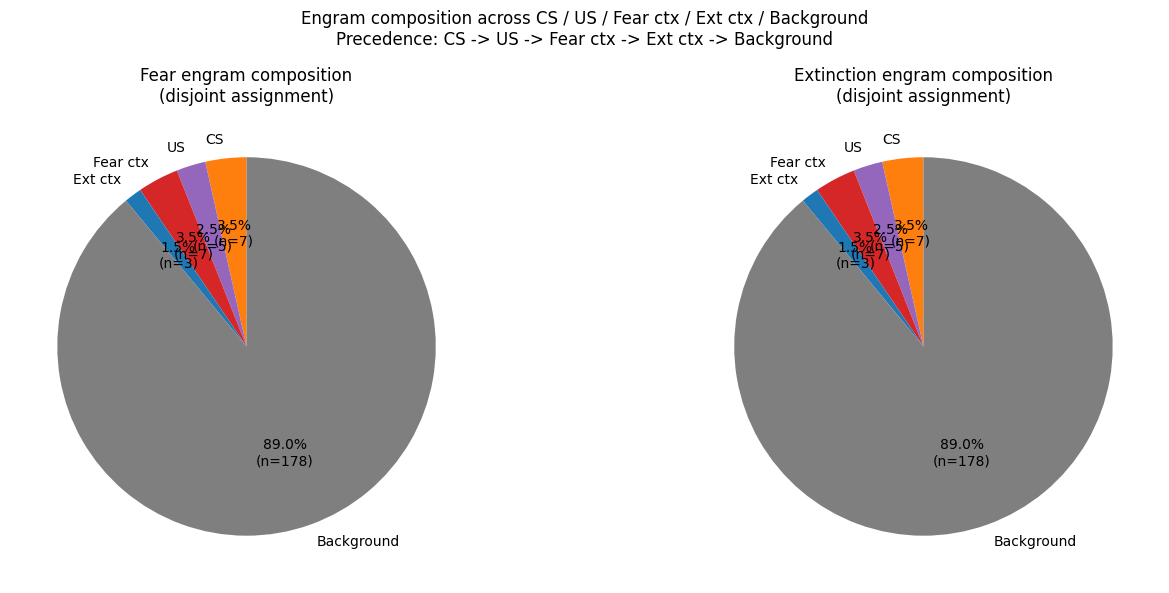

=== Engram composition (disjoint counts, sums to K) ===
Fear counts by category: {'CS': 7, 'US': 5, 'Fear ctx': 7, 'Ext ctx': 3, 'Background': 178}
Ext counts by category:  {'CS': 7, 'US': 5, 'Fear ctx': 7, 'Ext ctx': 3, 'Background': 178}

=== Multi-cue diagnostic (not separate pie slice) ===
Fear engram neurons in >=2 cue vectors: 0 / 200
Ext engram neurons in >=2 cue vectors:  0 / 200
Section E.1 complete


In [13]:
# Disjoint assignment for requested 5-category pies
# Precedence: CS -> US -> Fear ctx -> Ext ctx -> Background

labels = ["CS", "US", "Fear ctx", "Ext ctx", "Background"]
colors = ["#ff7f0e", "#9467bd", "#d62728", "#1f77b4", "#7f7f7f"]


def engram_category_counts(engram, cs, us, ctx_fear, ctx_ext):
    # Boolean masks
    e = engram == 1
    cs_m = cs == 1
    us_m = us == 1
    cf_m = ctx_fear == 1
    ce_m = ctx_ext == 1

    # Precedence-based disjoint bins
    cs_bin = e & cs_m
    us_bin = e & (~cs_m) & us_m
    cf_bin = e & (~cs_m) & (~us_m) & cf_m
    ce_bin = e & (~cs_m) & (~us_m) & (~cf_m) & ce_m
    bg_bin = e & (~cs_m) & (~us_m) & (~cf_m) & (~ce_m)

    counts = np.array([
        int(np.sum(cs_bin)),
        int(np.sum(us_bin)),
        int(np.sum(cf_bin)),
        int(np.sum(ce_bin)),
        int(np.sum(bg_bin)),
    ])

    # Diagnostic: neurons in this engram that lie in >=2 cue vectors
    cue_membership = cs_m.astype(int) + us_m.astype(int) + cf_m.astype(int) + ce_m.astype(int)
    multi_cue_count = int(np.sum(e & (cue_membership >= 2)))

    return counts, multi_cue_count


def autopct_with_count(total):
    def _fmt(pct):
        n = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={n})"
    return _fmt


fear_counts, fear_multi = engram_category_counts(fear_engram, cs_vec, us_vec, ctx_fear_vec, ctx_ext_vec)
ext_counts, ext_multi = engram_category_counts(ext_engram, cs_vec, us_vec, ctx_fear_vec, ctx_ext_vec)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    fear_counts,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct=autopct_with_count(int(np.sum(fear_counts))),
    textprops={"fontsize": 10},
)
axes[0].set_title("Fear engram composition\n(disjoint assignment)")

axes[1].pie(
    ext_counts,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct=autopct_with_count(int(np.sum(ext_counts))),
    textprops={"fontsize": 10},
)
axes[1].set_title("Extinction engram composition\n(disjoint assignment)")

plt.suptitle(
    "Engram composition across CS / US / Fear ctx / Ext ctx / Background\n"
    "Precedence: CS -> US -> Fear ctx -> Ext ctx -> Background",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGDIR / "04_engram_composition_pies.png", dpi=150)
plt.show()

print("=== Engram composition (disjoint counts, sums to K) ===")
print(f"Fear counts by category: {dict(zip(labels, fear_counts.tolist()))}")
print(f"Ext counts by category:  {dict(zip(labels, ext_counts.tolist()))}")
print()
print("=== Multi-cue diagnostic (not separate pie slice) ===")
print(f"Fear engram neurons in >=2 cue vectors: {fear_multi} / {int(np.sum(fear_engram))}")
print(f"Ext engram neurons in >=2 cue vectors:  {ext_multi} / {int(np.sum(ext_engram))}")
print("Section E.1 complete")

## Section F: Multi-trial retrieval (component fields, no US inhibition)


Cue condition                     Fear          Ext          Old   Winner
---------------------------------------------------------------------------
CS only                   1.000±0.000  1.000±0.000  0.097       TIE
CS + fear ctx             1.000±0.000  1.000±0.000  0.097       TIE
CS + ext ctx              0.080±0.002  0.080±0.002  0.107       TIE
CS + fear ctx + US        1.000±0.000  1.000±0.000  0.097       TIE

Which memory wins (FEAR / EXT / TIE) — by mean overlap:
  CS only: TIE
  CS + fear ctx: TIE
  CS + ext ctx: TIE
  CS + fear ctx + US: TIE


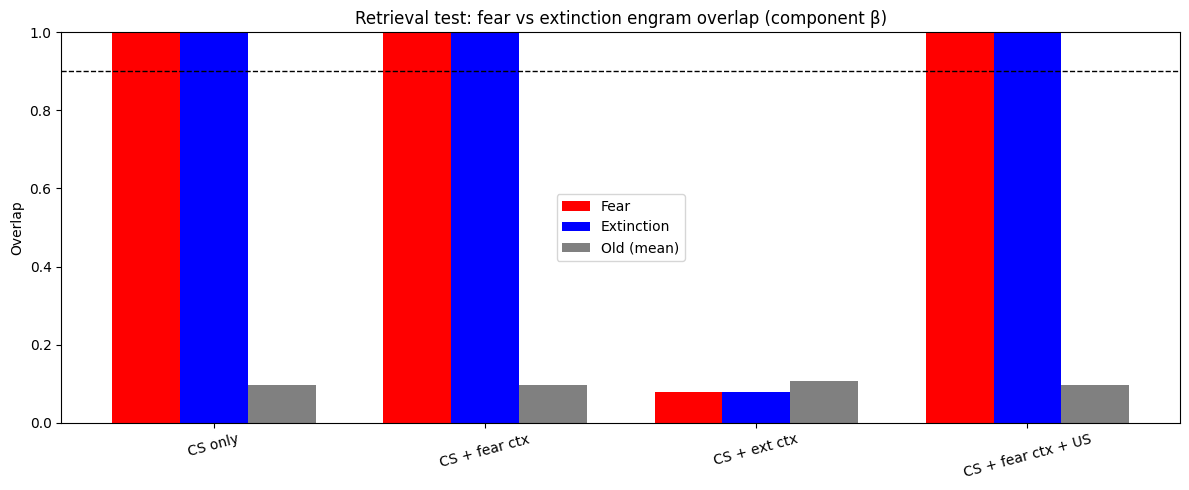

Section F complete


In [14]:
def make_retrieval_field(cs_on, ctx_vec, us_on):
    field = np.zeros(N)
    if cs_on:
        field += BETA_CS_FEAR * cs_vec
    if ctx_vec is not None:
        field += BETA_CTX_RETRIEVAL * ctx_vec
    if us_on:
        field += BETA_US_FEAR * us_vec
    return field


def retrieve_topk_field(net, ext_field, excitability_bias, N, K, max_steps):
    init = (ext_field > 0).astype(float)
    state = init.copy()
    for step in range(max_steps):
        h = net.W @ state + ext_field + excitability_bias
        topk_idx = np.argpartition(h, -K)[-K:]
        new_state = np.zeros(N)
        new_state[topk_idx] = 1.0
        if np.array_equal(new_state, state):
            break
        state = new_state
    return state


def memory_winner(f_mean, e_mean, eps=0.01):
    if f_mean > e_mean + eps:
        return "FEAR"
    if e_mean > f_mean + eps:
        return "EXT"
    return "TIE"


retrieval_fields = {
    "CS only": make_retrieval_field(True, None, False),
    "CS + fear ctx": make_retrieval_field(True, ctx_fear_vec, False),
    "CS + ext ctx": make_retrieval_field(True, ctx_ext_vec, False),
    "CS + fear ctx + US": make_retrieval_field(True, ctx_fear_vec, True),
}

test_labels = list(retrieval_fields.keys())
all_results = {label: {"fear": [], "ext": [], "old": []} for label in test_labels}

rng_retrieval = np.random.default_rng(SEED + 100)

for trial in range(N_RETRIEVAL_TRIALS):
    theta_ret = rng_retrieval.normal(0, SIGMA_THETA, N)
    for label, field in retrieval_fields.items():
        final = retrieve_topk_field(
            net, field, theta_ret, N, K, MAX_STEPS_RETRIEVAL
        )
        all_results[label]["fear"].append(pattern_overlap(final, fear_engram))
        all_results[label]["ext"].append(pattern_overlap(final, ext_engram))
        all_results[label]["old"].append(
            np.mean([pattern_overlap(final, p) for p in old_patterns[:10]])
        )

print(f"\n{'Cue condition':<25} {'Fear':>12} {'Ext':>12} {'Old':>12} {'Winner':>8}")
print("-" * 75)
for label in test_labels:
    f_mean = np.mean(all_results[label]["fear"])
    f_std = np.std(all_results[label]["fear"])
    e_mean = np.mean(all_results[label]["ext"])
    e_std = np.std(all_results[label]["ext"])
    o_mean = np.mean(all_results[label]["old"])
    win = memory_winner(f_mean, e_mean)
    print(
        f"{label:<25} "
        f"{f_mean:.3f}±{f_std:.3f}  "
        f"{e_mean:.3f}±{e_std:.3f}  "
        f"{o_mean:.3f}  {win:>8}"
    )

print("\nWhich memory wins (FEAR / EXT / TIE) — by mean overlap:")
for label in test_labels:
    fm = np.mean(all_results[label]["fear"])
    em = np.mean(all_results[label]["ext"])
    print(f"  {label}: {memory_winner(fm, em)}")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(test_labels))
w = 0.25
ax.bar(x - w, [np.mean(all_results[l]["fear"]) for l in test_labels], w, label="Fear", color="red")
ax.bar(x, [np.mean(all_results[l]["ext"]) for l in test_labels], w, label="Extinction", color="blue")
ax.bar(x + w, [np.mean(all_results[l]["old"]) for l in test_labels], w, label="Old (mean)", color="gray")
ax.axhline(0.9, linestyle="--", color="k", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(test_labels, rotation=15)
ax.set_ylabel("Overlap")
ax.set_ylim(0, 1)
ax.set_title("Retrieval test: fear vs extinction engram overlap (component β)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "04_retrieval_inhibitory.png", dpi=150)
plt.show()

print("Section F complete")


## Interpreting Section F outcomes

Run the **next cell** after Section F to turn the overlap table into plain-language conclusions.

**What the numbers mean**

- **Fear / Ext** use `pattern_overlap(final, engram)`: *what fraction of that engram’s active neurons are on in the retrieved state*. High **Fear** means the fixed point **looks like the fear memory**, not that both memories are equally expressed.
- **φ (phi)** is how much the **two stored engrams** co-occupy neurons (normalized by `K`). If **Ext ≈ φ** while **Fear ≈ 1**, extinction is **not** being retrieved as a separate attractor; the low Ext score mostly reflects **geometric overlap** between engrams, not “partial extinction.”

**How to read “who wins”**

- **FEAR** in the table means the retrieved state overlaps the fear engram more than the extinction engram under that definition—not necessarily “more biological fear,” but **more Hopfield overlap with the fear pattern**.
- If **all cue rows look identical**, small changes in the test cue did not change the attractor: **recurrent dynamics (`W·s`) plus noise θ** are steering to the **same** `K`-sparse state regardless of the extra context bits in the field.


In [382]:
def interpret_section_f_retrieval(
    all_results,
    test_labels,
    phi,
    *,
    overlap_high=0.85,
    phi_match_tol=0.08,
    cue_flat_atol=0.03,
    eps_winner=0.01,
):
    """
    Plain-language readout of Section F multi-trial retrieval overlaps.

    Expects `all_results[label]['fear'|'ext']` lists and scalar `phi` from Section E.
    """

    def _mean(label, key):
        return float(np.mean(all_results[label][key]))

    def _join(parts):
        return " ".join(parts)

    print("=== Intuitive interpreter (Section F) ===\n")

    fear_means = [_mean(l, "fear") for l in test_labels]
    ext_means = [_mean(l, "ext") for l in test_labels]

    print(
        "Metric: overlap(final, engram) = fraction of that engram's K neurons "
        "that are active in `final`. High Fear means state ~ fear pattern.\n"
    )

    # Cross-condition: same attractor?
    f_spread = max(fear_means) - min(fear_means)
    e_spread = max(ext_means) - min(ext_means)
    if f_spread <= cue_flat_atol and e_spread <= cue_flat_atol:
        print(
            "• Cue insensitivity: Fear and Ext means barely change across cue "
            "conditions. The recurrent term is landing in the SAME fixed point; "
            "small field tweaks are not enough to hop basins.\n"
        )
    else:
        print(
            "• Cue sensitivity: At least one cue condition shifts the mean overlaps "
            f"(Fear spread ≈ {f_spread:.3f}, Ext spread ≈ {e_spread:.3f}).\n"
        )

    # Per-row + phi story
    for label in test_labels:
        fm = _mean(label, "fear")
        em = _mean(label, "ext")
        tag = []
        if fm >= overlap_high and abs(em - phi) <= phi_match_tol:
            tag.append("fear-locked (Ext ~ phi: not retrieving extinction)")
        elif fm >= overlap_high and em >= overlap_high:
            tag.append("mixed / ambiguous (both overlaps high)")
        elif em > fm + eps_winner:
            tag.append("extinction-favored")
        elif fm > em + eps_winner:
            tag.append("fear-favored")
        else:
            tag.append("near tie")

        win = "FEAR" if fm > em + eps_winner else ("EXT" if em > fm + eps_winner else "TIE")
        print(f"• {label}: Fear={fm:.3f}, Ext={em:.3f} → {win}. {_join(tag)}")

    print(
        f"\n• φ check: φ = {phi:.3f}. If Ext ≈ φ while Fear ≈ 1, the table is "
        "consistent with retrieving the fear engram; Ext column reflects "
        "shared neurons, not extinction as its own attractor."
    )

    print(
        "\n• Design reminder (this notebook): Fear storage uses stronger CS β than "
        "extinction; Section F retrieval omits extinction US inhibition. Both "
        "tilt CS-biased tests toward the fear-shaped attractor unless parameters "
        "or cues separate basins more strongly."
    )


# Run after Section F (needs all_results, test_labels, phi)
interpret_section_f_retrieval(all_results, test_labels, phi)


=== Intuitive interpreter (Section F) ===

Metric: overlap(final, engram) = fraction of that engram's K neurons that are active in `final`. High Fear means state ~ fear pattern.

• Cue sensitivity: At least one cue condition shifts the mean overlaps (Fear spread ≈ 0.918, Ext spread ≈ 0.918).

• CS only: Fear=1.000, Ext=1.000 → TIE. fear-locked (Ext ~ phi: not retrieving extinction)
• CS + fear ctx: Fear=1.000, Ext=1.000 → TIE. fear-locked (Ext ~ phi: not retrieving extinction)
• CS + ext ctx: Fear=0.082, Ext=0.082 → TIE. near tie
• CS + fear ctx + US: Fear=1.000, Ext=1.000 → TIE. fear-locked (Ext ~ phi: not retrieving extinction)

• φ check: φ = 1.000. If Ext ≈ φ while Fear ≈ 1, the table is consistent with retrieving the fear engram; Ext column reflects shared neurons, not extinction as its own attractor.

• Design reminder (this notebook): Fear storage uses stronger CS β than extinction; Section F retrieval omits extinction US inhibition. Both tilt CS-biased tests toward the fear-sha

## Is CS-alone ambiguity a feature or a bug?

How CS neurons in each engram sit relative to the CS-only retrieval field and top-k threshold.

In [383]:
cue_cs_only = cs_vec.astype(float)
cue_cs_fear_ctx = np.clip(cs_vec + ctx_fear_vec, 0, 1)
cue_cs_ext_ctx = np.clip(cs_vec + ctx_ext_vec, 0, 1)

rng_amb = np.random.default_rng(SEED + 333)
theta_retrieval_example = rng_amb.normal(0, SIGMA_THETA, N)

fear_cs_count = int(np.sum(fear_engram * cs_vec))
ext_cs_count = int(np.sum(ext_engram * cs_vec))
shared_cs = int(np.sum(fear_engram * ext_engram * cs_vec))

print("CS representation in each engram:")
print(f"  CS neurons in fear engram:       {fear_cs_count}")
print(f"  CS neurons in ext engram:        {ext_cs_count}")
print(f"  CS neurons in BOTH engrams:      {shared_cs}")
print(
    f"  CS neurons in NEITHER engram:    "
    f"{N_CUE - fear_cs_count - ext_cs_count + shared_cs}"
)
print()

h_cs_only = net.W @ cue_cs_only.astype(float) + BETA_CS_FEAR * cs_vec + theta_retrieval_example
threshold_cs = np.sort(h_cs_only)[-K]

cs_in_fear_fields = h_cs_only[fear_engram * cs_vec == 1]
cs_in_ext_fields = h_cs_only[ext_engram * cs_vec == 1]

print("At CS-only retrieval onset:")
print(
    f"  Mean field of CS-fear neurons: "
    f"{float(np.mean(cs_in_fear_fields)) if cs_in_fear_fields.size else float('nan'):.4f}"
)
print(
    f"  Mean field of CS-ext neurons:  "
    f"{float(np.mean(cs_in_ext_fields)) if cs_in_ext_fields.size else float('nan'):.4f}"
)
print(f"  Top-k threshold:               {threshold_cs:.4f}")
print()
pct_fear = (
    float(np.mean(cs_in_fear_fields > threshold_cs)) * 100
    if cs_in_fear_fields.size
    else float("nan")
)
pct_ext = (
    float(np.mean(cs_in_ext_fields > threshold_cs)) * 100
    if cs_in_ext_fields.size
    else float("nan")
)
print(f"  % of CS-fear neurons above threshold: {pct_fear:.0f}%")
print(f"  % of CS-ext neurons above threshold:  {pct_ext:.0f}%")
print()
print("Interpretation:")
print("  If CS-ext % >> CS-fear %: CS cue biased toward extinction")
print("  If roughly equal: CS is genuinely ambiguous")
print("  If CS-fear % >> CS-ext %: CS should retrieve fear")
print()
print("Design target:")
print("  CS alone     -> ambiguous (both ~0.5) or fear slight edge")
print("  CS+fear ctx  -> fear wins clearly (>0.8)")
print("  CS+ext ctx   -> extinction wins clearly (>0.8)")
print("  CS+fear+US   -> fear wins decisively (>0.9)")

print("CS-alone ambiguity diagnostic complete")


CS representation in each engram:
  CS neurons in fear engram:       7
  CS neurons in ext engram:        7
  CS neurons in BOTH engrams:      7
  CS neurons in NEITHER engram:    53

At CS-only retrieval onset:
  Mean field of CS-fear neurons: 0.1878
  Mean field of CS-ext neurons:  0.1878
  Top-k threshold:               0.0644

  % of CS-fear neurons above threshold: 100%
  % of CS-ext neurons above threshold:  100%

Interpretation:
  If CS-ext % >> CS-fear %: CS cue biased toward extinction
  If roughly equal: CS is genuinely ambiguous
  If CS-fear % >> CS-ext %: CS should retrieve fear

Design target:
  CS alone     -> ambiguous (both ~0.5) or fear slight edge
  CS+fear ctx  -> fear wins clearly (>0.8)
  CS+ext ctx   -> extinction wins clearly (>0.8)
  CS+fear+US   -> fear wins decisively (>0.9)
CS-alone ambiguity diagnostic complete


## Retrieval step diagnostics

This cell explains **why** a cue wins by tracking the field distribution through retrieval.

It reports, at each update step:
- the top-`K` threshold (`K`th largest field),
- the `K` vs `K+1` margin,
- mean and spread of fields for fear, extinction, and background neurons,
- how many fear-engram / extinction-engram neurons currently occupy the top-`K` set.

Interpretation guide:
- If the threshold is low but the **margin is tiny**, the system is sensitive and many neurons are near-competitive.
- If fear and extinction neurons are both well above threshold initially, the cue is **not selective**.
- If fear occupancy in the top-`K` grows across steps while extinction occupancy falls, recurrent dynamics are **pulling the state into the fear basin**.
- Because this notebook uses strict top-`K`, the number of active neurons stays fixed at `K`; the important quantity is **who gets into the top-`K`**, not how many neurons are active overall.

In [337]:
def retrieval_step_diagnostics(
    net,
    cue_field,
    theta,
    fear_engram,
    ext_engram,
    *,
    label="cue",
    max_steps=MAX_STEPS_RETRIEVAL,
):
    """Track top-k competition during retrieval for one cue field."""
    state = (cue_field > 0).astype(float)
    rows = []

    for step in range(max_steps + 1):
        h = net.W @ state + cue_field + theta
        h_sorted = np.sort(h)
        threshold = float(h_sorted[-K])
        next_best = float(h_sorted[-(K + 1)]) if K < len(h_sorted) else float("nan")
        margin = threshold - next_best if np.isfinite(next_best) else float("nan")

        top_idx = np.argpartition(h, -K)[-K:]
        top_mask = np.zeros(N, dtype=bool)
        top_mask[top_idx] = True

        fear_in_topk = int(np.sum(top_mask & (fear_engram == 1)))
        ext_in_topk = int(np.sum(top_mask & (ext_engram == 1)))
        both_in_topk = int(np.sum(top_mask & (fear_engram == 1) & (ext_engram == 1)))

        fear_vals = h[fear_engram == 1]
        ext_vals = h[ext_engram == 1]
        bg_vals = h[(fear_engram == 0) & (ext_engram == 0)]

        rows.append(
            {
                "step": step,
                "threshold": threshold,
                "margin": margin,
                "fear_mean": float(np.mean(fear_vals)),
                "fear_std": float(np.std(fear_vals)),
                "ext_mean": float(np.mean(ext_vals)),
                "ext_std": float(np.std(ext_vals)),
                "bg_mean": float(np.mean(bg_vals)),
                "bg_std": float(np.std(bg_vals)),
                "fear_in_topk": fear_in_topk,
                "ext_in_topk": ext_in_topk,
                "both_in_topk": both_in_topk,
                "fear_overlap": float(pattern_overlap(top_mask.astype(float), fear_engram)),
                "ext_overlap": float(pattern_overlap(top_mask.astype(float), ext_engram)),
            }
        )

        new_state = np.zeros(N)
        new_state[top_idx] = 1.0
        if step == max_steps or np.array_equal(new_state, state):
            break
        state = new_state

    print(f"=== Retrieval step diagnostics: {label} ===")
    print(
        f"{'step':<4} {'thr':>8} {'margin':>8} {'fear_mu':>9} {'ext_mu':>9} {'bg_mu':>9} "
        f"{'fear@K':>7} {'ext@K':>7} {'both@K':>8} {'fear_ov':>8} {'ext_ov':>8}"
    )
    print("-" * 96)
    for r in rows:
        print(
            f"{r['step']:<4d} "
            f"{r['threshold']:>8.4f} {r['margin']:>8.4f} "
            f"{r['fear_mean']:>9.4f} {r['ext_mean']:>9.4f} {r['bg_mean']:>9.4f} "
            f"{r['fear_in_topk']:>7d} {r['ext_in_topk']:>7d} {r['both_in_topk']:>8d} "
            f"{r['fear_overlap']:>8.3f} {r['ext_overlap']:>8.3f}"
        )

    print("\nQuick read:")
    if len(rows) >= 2:
        first = rows[0]
        last = rows[-1]
        print(
            f"  At onset, fear/ext means were {first['fear_mean']:.4f} / {first['ext_mean']:.4f} "
            f"with threshold {first['threshold']:.4f}."
        )
        print(
            f"  Through retrieval, fear@K changed {first['fear_in_topk']} -> {last['fear_in_topk']}, "
            f"ext@K changed {first['ext_in_topk']} -> {last['ext_in_topk']}."
        )
        if last['fear_overlap'] > last['ext_overlap'] + 0.05:
            print("  Recurrent dynamics favored the fear basin.")
        elif last['ext_overlap'] > last['fear_overlap'] + 0.05:
            print("  Recurrent dynamics favored the extinction basin.")
        else:
            print("  Recurrent dynamics stayed mixed / ambiguous.")
        if first['fear_mean'] > first['threshold'] and first['ext_mean'] > first['threshold']:
            print("  Both engram populations started above threshold on average: the cue is broad, not selective.")
        if np.isfinite(first['margin']) and first['margin'] < 0.01:
            print("  The onset top-k margin is tiny: competition near the cutoff is tight.")
        elif np.isfinite(first['margin']):
            print("  The onset top-k margin is not tiny: the cutoff is fairly stable.")

    return rows


rng_diag = np.random.default_rng(SEED + 444)
theta_diag = rng_diag.normal(0, SIGMA_THETA, N)

cue_fields_diag = {
    "CS only": cue_cs_only.astype(float),
    "CS + fear ctx": cue_cs_fear_ctx.astype(float),
    "CS + ext ctx": cue_cs_ext_ctx.astype(float),
    "CS + fear ctx + US": np.clip(cs_vec + ctx_fear_vec + us_vec, 0, 1).astype(float),
}

retrieval_diag_rows = {}
for diag_label, diag_field in cue_fields_diag.items():
    retrieval_diag_rows[diag_label] = retrieval_step_diagnostics(
        net,
        diag_field,
        theta_diag,
        fear_engram,
        ext_engram,
        label=diag_label,
    )
    print()

=== Retrieval step diagnostics: CS only ===
step      thr   margin   fear_mu    ext_mu     bg_mu  fear@K   ext@K   both@K  fear_ov   ext_ov
------------------------------------------------------------------------------------------------
0      0.0494   0.0001    0.0501    0.0501    0.0271      31      31       31    0.155    0.155
1      0.2890   0.0027    0.1953    0.1953    0.0086      43      43       43    0.215    0.215
2      0.3461   0.0020    0.3733    0.3733   -0.0113      87      87       87    0.435    0.435
3      0.8750   0.0005    1.0273    1.0273   -0.0841     163     163      163    0.815    0.815
4      1.9858   1.0225    2.1657    2.1657   -0.2106     200     200      200    1.000    1.000
5      2.5792   1.8018    2.7153    2.7153   -0.2719     200     200      200    1.000    1.000

Quick read:
  At onset, fear/ext means were 0.0501 / 0.0501 with threshold 0.0494.
  Through retrieval, fear@K changed 31 -> 200, ext@K changed 31 -> 200.
  Recurrent dynamics stayed mix

## Part 9: Interpretation

- Storage uses **summed component fields**; extinction storage includes **negative β on US**.
- Retrieval uses **positive β only** (US off or reinstatement with `BETA_US_FEAR`).
- `BETA_US_EXT` is fixed in Section A and used consistently throughout this notebook.

## Sweep: fear context storage beta (`BETA_CTX_FEAR_STORE`)

Rebuild network per value; extinction uses fixed `BETA_US_EXT` from Section A. Retrieval uses `BETA_CTX_RETRIEVAL` for context cues.

In [338]:
ctx_fear_betas = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]

print("\nFear context beta sweep (BETA_US_EXT fixed from Section A):")
print(
    f"{'ctx_beta':<10} {'phi':>6} {'fear_CS':>8} "
    f"{'ext_CS':>8} {'CS->f':>7} {'CS->e':>7} "
    f"{'CS+fctx->f':>11} {'CS+ectx->e':>11}"
)
print("-" * 75)

rng_ctx_sweep = np.random.default_rng(SEED + 400)


def qr(net_c, cue_vec, beta_cs, beta_ctx, ctx_v, th_r_c):
    field = beta_cs * cs_vec
    if ctx_v is not None:
        field = field + beta_ctx * ctx_v
    s = cue_vec.copy().astype(float)
    for _ in range(MAX_STEPS_RETRIEVAL):
        h = net_c.W @ s + field + th_r_c
        idx = np.argpartition(h, -K)[-K:]
        ns = np.zeros(N)
        ns[idx] = 1.0
        if np.array_equal(ns, s):
            break
        s = ns
    return s


for ctx_b in ctx_fear_betas:
    net_c = HopfieldNetwork(
        n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY
    )
    old_c = [
        generate_sparse_pattern(N, SPARSITY, rng=rng_ctx_sweep).astype(float)
        for _ in range(P_OLD)
    ]
    net_c.store_patterns(old_c)

    th_f_c = rng_ctx_sweep.normal(0, SIGMA_THETA, N)
    th_e_c = rng_ctx_sweep.normal(0, SIGMA_THETA, N)

    fc = {
        "cs": (cs_vec, BETA_CS_FEAR),
        "us": (us_vec, BETA_US_FEAR),
        "ctx": (ctx_fear_vec, ctx_b),
    }
    f_field = compute_ext_field(fc)
    state = (f_field > 0).astype(float)
    for _ in range(MAX_STEPS_STORAGE):
        h = net_c.W @ state + f_field + th_f_c
        idx = np.argpartition(h, -K)[-K:]
        ns = np.zeros(N)
        ns[idx] = 1.0
        if np.array_equal(ns, state):
            break
        state = ns
    f_eng_c = state.copy()
    net_c.store_pattern_sequential(f_eng_c)

    ec = {
        "cs": (cs_vec, BETA_CS_EXT),
        "us": (us_vec, BETA_US_EXT),
        "ctx": (ctx_ext_vec, BETA_CTX_EXT_STORE),
    }
    e_field = compute_ext_field(ec)
    state = (e_field > 0).astype(float)
    for _ in range(MAX_STEPS_STORAGE):
        h = net_c.W @ state + e_field + th_e_c
        idx = np.argpartition(h, -K)[-K:]
        ns = np.zeros(N)
        ns[idx] = 1.0
        if np.array_equal(ns, state):
            break
        state = ns
    e_eng_c = state.copy()
    net_c.store_pattern_sequential(e_eng_c)

    phi_c = np.sum(f_eng_c * e_eng_c) / K
    fcs = np.sum(f_eng_c * cs_vec) / N_CUE
    ecs = np.sum(e_eng_c * cs_vec) / N_CUE

    th_r_c = rng_ctx_sweep.normal(0, SIGMA_THETA, N)

    s_cf = qr(net_c, cue_cs_only, BETA_CS_FEAR, 0, None, th_r_c)
    s_cff = qr(net_c, cue_cs_fear_ctx, BETA_CS_FEAR, BETA_CTX_RETRIEVAL, ctx_fear_vec, th_r_c)
    s_cee = qr(net_c, cue_cs_ext_ctx, BETA_CS_FEAR, BETA_CTX_RETRIEVAL, ctx_ext_vec, th_r_c)

    cf = pattern_overlap(s_cf, f_eng_c)
    ce = pattern_overlap(s_cf, e_eng_c)
    cff = pattern_overlap(s_cff, f_eng_c)
    cee = pattern_overlap(s_cee, e_eng_c)

    good = phi_c < 0.5 and cff > 0.5
    flag = "GOOD" if good else ""

    print(
        f"{ctx_b:<10.2f} {phi_c:>6.3f} {fcs:>8.3f} "
        f"{ecs:>8.3f} {cf:>7.3f} {ce:>7.3f} "
        f"{cff:>11.3f} {cee:>11.3f}  {flag}"
    )

print("\nTarget: CS+fctx->f > 0.5, phi < 0.5, fear_CS >= ext_CS")
print("Fear context beta sweep complete")



Fear context beta sweep (BETA_US_EXT fixed at chosen):
ctx_beta      phi  fear_CS   ext_CS   CS->f   CS->e  CS+fctx->f  CS+ectx->e
---------------------------------------------------------------------------
0.20        0.065    0.100    0.133   0.065   1.000       1.000       1.000  GOOD
0.25        0.125    0.117    0.117   0.125   1.000       1.000       1.000  GOOD
0.30        0.100    0.117    0.167   0.100   1.000       0.100       1.000  
0.35        0.110    0.117    0.233   0.110   1.000       1.000       1.000  GOOD
0.40        0.105    0.133    0.133   1.000   0.105       1.000       1.000  GOOD
0.50        1.000    0.233    0.233   1.000   1.000       1.000       1.000  
0.60        1.000    0.167    0.167   1.000   1.000       1.000       1.000  

Target: CS+fctx->f > 0.5, phi < 0.5, fear_CS >= ext_CS
Fear context beta sweep complete


In [339]:
print("=== Summary ===")
print(
    f"N={N}, K={K}, P_OLD={P_OLD}, N_CUE={N_CUE}, "
    f"BETA_CS_FEAR={BETA_CS_FEAR}, BETA_CS_EXT={BETA_CS_EXT}, "
    f"BETA_CTX_FEAR_STORE={BETA_CTX_FEAR_STORE}, BETA_CTX_EXT_STORE={BETA_CTX_EXT_STORE}, "
    f"BETA_CTX_RETRIEVAL={BETA_CTX_RETRIEVAL}, "
    f"BETA_US_FEAR={BETA_US_FEAR}, BETA_US_EXT={BETA_US_EXT}"
)
print(f"Phi total: {np.sum(fear_engram * ext_engram) / K:.3f}")
print(
    "Retrieval winners: "
    + ", ".join(
        f"{lab}={memory_winner(np.mean(all_results[lab]['fear']), np.mean(all_results[lab]['ext']))}"
        for lab in test_labels
    )
)
print("Summary complete")


=== Summary ===
N=2000, K=200, P_OLD=42, N_CUE=60, BETA_CS_FEAR=0.2, BETA_CS_EXT=0.3, BETA_CTX_FEAR_STORE=0.5, BETA_CTX_EXT_STORE=0.5, BETA_CTX_RETRIEVAL=0.25, BETA_US_FEAR=0.2, BETA_US_EXT=-0.05
Phi total: 1.000
Retrieval winners: CS only=TIE, CS + fear ctx=TIE, CS + ext ctx=TIE, CS + fear ctx + US=TIE
Summary complete


## Part 10: Parameter tuning (component β)

- **BETA_US_EXT**: more negative → stronger suppression of US coordinates in the extinction field; use sweep (Section G) to target `phi` and capture diagnostics.
- **BETA_CS / BETA_CTX / BETA_US_FEAR**: raise if engram overlap vs CS/US/context sits near chance; lower if cues pin states too literally.
- **P_OLD**, **N_CUE**, **SIGMA_THETA**: same tradeoffs as before (recurrent load vs cue strength vs noise).

## Section E.2: Local-field histograms during learning (fear + extinction)

This mirrors the same onset histogram style, but now tracks **training dynamics** at three steps:
- onset
- midpoint
- final convergence

Top-k threshold is shown in each panel so you can see whether target engram neurons are above/below cutoff as training evolves.

In [ ]:
def _selected_training_steps(traj):
    n = len(traj)
    if n <= 1:
        return [0]
    mid = min(max(1, n // 2), n - 1)
    return sorted(set([0, mid, n - 1]))


def _plot_training_hist_row(axes_row, traj, ext_field, theta, target_engram, phase_label):
    steps = _selected_training_steps(traj)

    for ax, step_idx in zip(axes_row, steps):
        s = traj[step_idx].astype(float)
        h = net.W @ s + ext_field + theta
        threshold = np.sort(h)[-K]

        target_mask = target_engram == 1
        non_target_mask = target_engram == 0
        cs_target_mask = target_mask & (cs_vec == 1)
        us_target_mask = target_mask & (us_vec == 1)

        ax.hist(h[non_target_mask], bins=60, alpha=0.5, color="gray", label="Non-target neurons")
        ax.hist(h[target_mask], bins=30, alpha=0.7, color="red", label="Target engram neurons")
        if cs_target_mask.any():
            ax.hist(h[cs_target_mask], bins=15, alpha=0.9, color="orange", label="CS in target")
        if us_target_mask.any():
            ax.hist(h[us_target_mask], bins=15, alpha=0.9, color="purple", label="US in target")

        ax.axvline(threshold, color="black", linestyle="--", label="Top-k threshold")
        ax.set_title(f"{phase_label}: step {step_idx}")
        ax.set_xlabel("Local field")
        ax.set_ylabel("Count")

        print(
            f"{phase_label:<10} step={step_idx:<2d}  "
            f"threshold={threshold:>7.4f}  "
            f"target_mean={np.mean(h[target_mask]):>7.4f}  "
            f"nontarget_mean={np.mean(h[non_target_mask]):>7.4f}"
        )

    return steps


fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=False, sharey=False)

print("=== Local-field training diagnostics ===")
fear_steps = _plot_training_hist_row(
    axes[0],
    traj_fear,
    fear_ext_field,
    theta_fear,
    fear_engram,
    "Fear learn",
)
ext_steps = _plot_training_hist_row(
    axes[1],
    traj_ext,
    ext_ext_field,
    theta_ext,
    ext_engram,
    "Ext learn",
)

for ax in axes.flatten():
    ax.legend(fontsize=7)

plt.suptitle(
    "Training local-field distributions with top-k threshold\n"
    "Rows: fear learning, extinction learning | Columns: onset, midpoint, final",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(FIGDIR / "04_learning_field_histograms.png", dpi=150)
plt.show()

print(f"Fear plotted steps: {fear_steps}")
print(f"Ext plotted steps:  {ext_steps}")
print("Section E.2 complete")